# Affinity and Anti-Affinity Constraints

Goal: demonstrate, on hand-built instances, that the three solvers handle affinity and anti-affinity constraints. The notebook also checks a deadlock situation where the constraints are contradictory.

In [7]:
from IPython.display import display

from vm_allocation.models import Context, Server, VM
from vm_allocation.solvers import CPSATSolver, FFDSolver, PLNESolver

## Feasible Instance

VM 1 and VM 2 must be placed on the same server. VM 3 and VM 4 must be placed on different servers.

Available servers:
- s1: cpu=12, ram=16, storage=100, bw=20
- s2: cpu=12, ram=16, storage=100, bw=20

VMs to place:
- 1: cpu=4, ram=4, storage=20, bw=4
- 2: cpu=3, ram=3, storage=15, bw=3
- 3: cpu=5, ram=5, storage=25, bw=5
- 4: cpu=4, ram=4, storage=20, bw=4

Constraints:
- VM 1 must be on the same server as VM 2
- VM 3 must be on a different server from VM 4


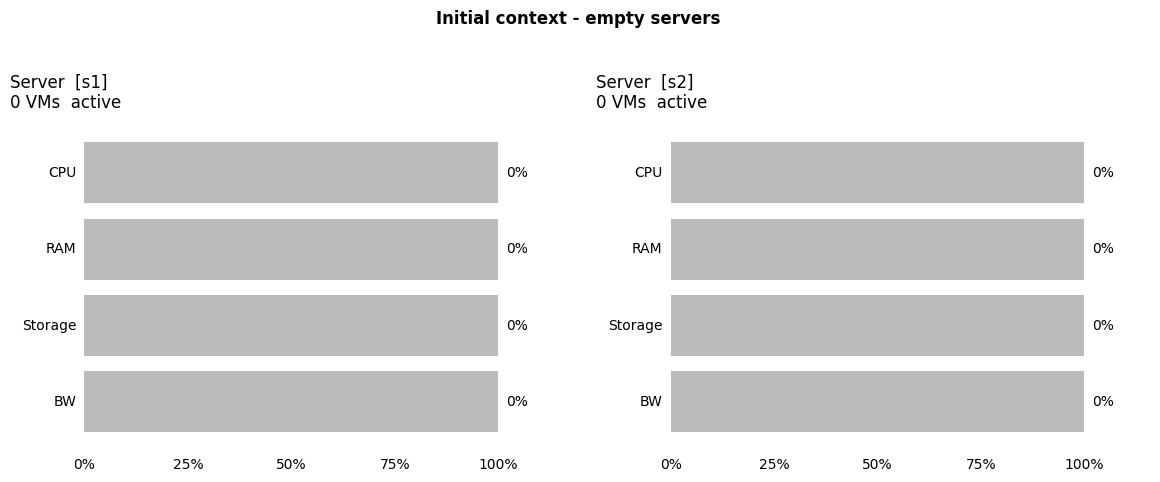

In [8]:
SERVERS = [
    Server("s1", cpu=12, ram=16, storage=100, bw=20),
    Server("s2", cpu=12, ram=16, storage=100, bw=20),
]

VMS = [
    VM("1", cpu=4, ram=4, storage=20, bw=4),
    VM("2", cpu=3, ram=3, storage=15, bw=3),
    VM("3", cpu=5, ram=5, storage=25, bw=5),
    VM("4", cpu=4, ram=4, storage=20, bw=4),
]

VMS[0].add_affinity(VMS[1])
VMS[2].add_anti_affinity(VMS[3])

SOLVERS = {
    "FFD": FFDSolver(),
    "PLNE": PLNESolver(),
    "CP-SAT": CPSATSolver(migration_weight=0, fragmentation_weight=0),
}


def copies(items):
    return [item.copy() for item in items]


print("Available servers:")
for server in SERVERS:
    print(f"- {server.id}: cpu={server.cpu_capacity}, ram={server.ram_capacity}, storage={server.storage_capacity}, bw={server.bw_capacity}")

print("\nVMs to place:")
for vm in VMS:
    print(f"- {vm.id}: cpu={vm.cpu}, ram={vm.ram}, storage={vm.storage}, bw={vm.bw}")

print("\nConstraints:")
print("- VM 1 must be on the same server as VM 2")
print("- VM 3 must be on a different server from VM 4")

display(Context(copies(SERVERS)).plot("Initial context - empty servers"))

## Constraint Check

For each solution, we first locate every VM. Then we verify that affinity pairs share the same server and anti-affinity pairs use different servers.


===== FFD CLEAN SOLVER =====
[DEBUG] total VMs = 4

FFD - VM locations
VM    Server
------------
1     s1
2     s1
3     s1
4     s2


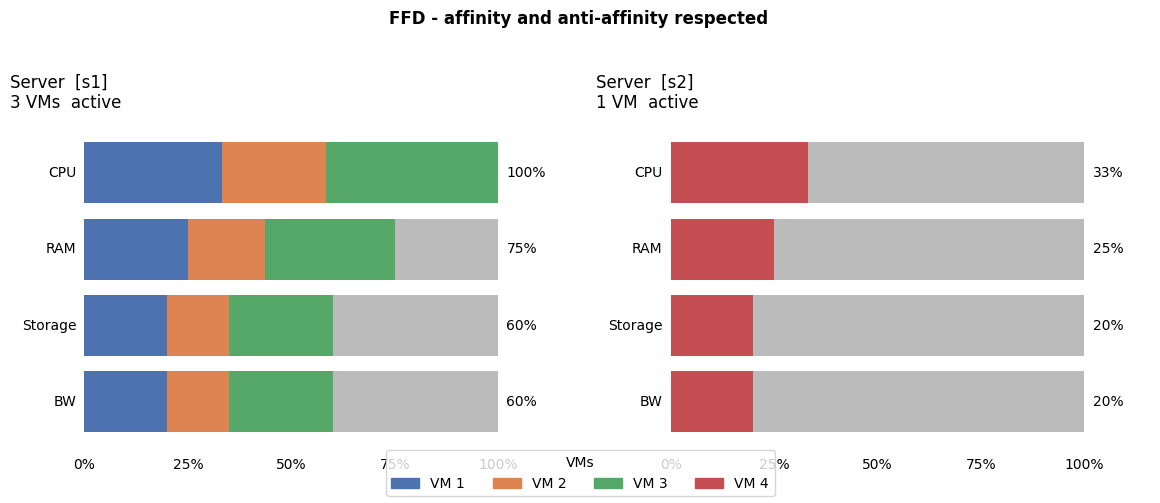


PLNE - VM locations
VM    Server
------------
1     s2
2     s2
3     s2
4     s1


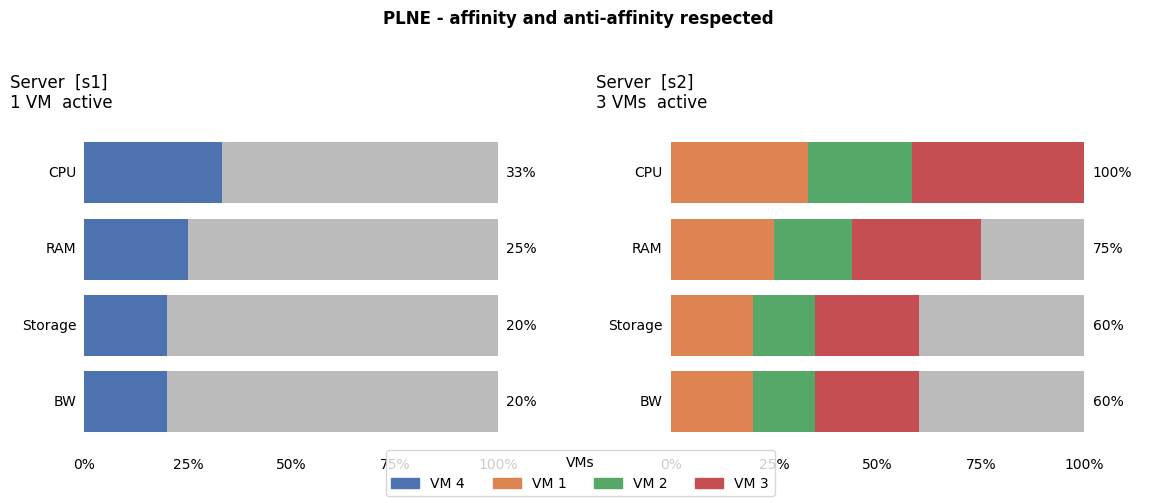


CP-SAT - VM locations
VM    Server
------------
1     s2
2     s2
3     s2
4     s1


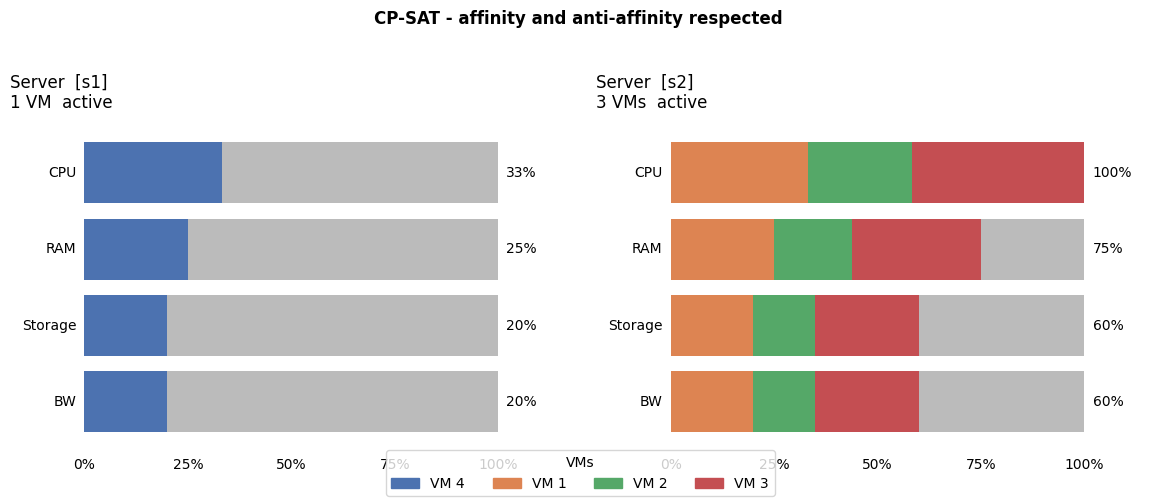


All solvers respect the affinity and anti-affinity constraints on the feasible instance.


In [9]:
def vm_locations(context):
    locations = {}

    for server in context.get_servers():
        for vm in server.vms:
            locations.setdefault(vm.id, []).append(server.id)

    return locations


def relation_errors(context, vms):
    locations = vm_locations(context)
    errors = []
    checked_relations = set()

    for vm in vms:
        if len(locations.get(vm.id, [])) != 1:
            errors.append(f"VM {vm.id} is not placed exactly once")

    for vm in vms:
        for other_id in vm.affinity:
            relation = ("affinity", tuple(sorted([vm.id, other_id])))
            if relation in checked_relations:
                continue

            checked_relations.add(relation)
            vm_server = locations.get(vm.id, [None])[0]
            other_server = locations.get(other_id, [None])[0]

            if vm_server != other_server:
                errors.append(f"VM {vm.id} and VM {other_id} should be together")

        for other_id in vm.anti_affinity:
            relation = ("anti_affinity", tuple(sorted([vm.id, other_id])))
            if relation in checked_relations:
                continue

            checked_relations.add(relation)
            vm_server = locations.get(vm.id, [None])[0]
            other_server = locations.get(other_id, [None])[0]

            if vm_server == other_server:
                errors.append(f"VM {vm.id} and VM {other_id} should be separated")

    return errors


solutions = {}

for solver_name, solver in SOLVERS.items():
    solution = solver.solve(copies(VMS), Context(copies(SERVERS)))
    assert solution is not None, f"{solver_name} did not find a feasible solution"

    errors = relation_errors(solution, VMS)
    assert not errors, errors
    solutions[solver_name] = solution

    print(f"\n{solver_name} - VM locations")
    print("VM    Server")
    print("------------")
    for vm_id, servers in sorted(vm_locations(solution).items()):
        print(f"{vm_id:<6}{servers[0]}")

    display(solution.plot(f"{solver_name} - affinity and anti-affinity respected"))

print("\nAll solvers respect the affinity and anti-affinity constraints on the feasible instance.")

## Deadlock Instance

This instance is impossible: VM 1 and VM 2 must be on the same server and on different servers at the same time. A valid allocation must not exist.

In [10]:
DEADLOCK_VMS = [
    VM("1", cpu=2, ram=2, storage=10, bw=2),
    VM("2", cpu=2, ram=2, storage=10, bw=2),
]

DEADLOCK_VMS[0].add_affinity(DEADLOCK_VMS[1])
DEADLOCK_VMS[0].add_anti_affinity(DEADLOCK_VMS[1])

for solver_name, solver in SOLVERS.items():
    solution = solver.solve(copies(DEADLOCK_VMS), Context(copies(SERVERS)))

    if solution is None:
        print(f"{solver_name}: deadlock correctly rejected")
        continue

    errors = relation_errors(solution, DEADLOCK_VMS)
    assert errors, f"{solver_name} produced a valid solution for an impossible instance"
    print(f"{solver_name}: deadlock produced no valid allocation")
    print(errors)


===== FFD CLEAN SOLVER =====
[DEBUG] total VMs = 2
[FAIL] cannot place group
FFD: deadlock correctly rejected
PLNE: deadlock correctly rejected
CP-SAT: deadlock correctly rejected


## Feasible Placement Details

In [11]:
for solver_name, solution in solutions.items():
    print(f"\n===== {solver_name} =====")
    print(solution)


===== FFD =====
===== Context - 2 servers, 4 VMs total =====

┌─ Server [s1] ─── 3 VMs ──────────────────────────────────────────────────────────────────────┐
│  CPU     [████████████████████████████████████████████████████████████████]    12/12  (100%) │
│  RAM     [████████████████████████████████████████████████░░░░░░░░░░░░░░░░]    12/16  ( 75%) │
│  Storage [██████████████████████████████████████░░░░░░░░░░░░░░░░░░░░░░░░░░]   60/100  ( 60%) │
│  BW      [██████████████████████████████████████░░░░░░░░░░░░░░░░░░░░░░░░░░]    12/20  ( 60%) │
│  VMs:                                                                                        │
│    · VM[1](cpu=4, ram=4, sto=20, bw=4, aff={'2'})                                            │
│    · VM[2](cpu=3, ram=3, sto=15, bw=3, aff={'1'})                                            │
│    · VM[3](cpu=5, ram=5, sto=25, bw=5, anti={'4'})                                           │
└───────────────────────────────────────────────────────────────